# PyTorch 기반 최근접 이웃(KNN) 분류 실습

## 실습 목표

최근접 이웃(k-Nearest Neighbors, KNN) 분류 흐름을 PyTorch 코드로 구현한 것입니다.

핵심 흐름은 다음과 같습니다.

1. Wisconsin 유방암 데이터 불러오기
2. `id` 컬럼 제거
3. `diagnosis` 라벨 변환
4. Min-Max 정규화 또는 Z-score 표준화
5. 훈련/테스트 데이터 분리
6. KNN 분류 예측
7. 혼동행렬과 정확도 평가
8. 여러 `k` 값 비교

PyTorch는 KNN 전용 모델을 기본 제공하지 않기 때문에, 여기서는 `torch.cdist()`를 사용하여 거리 계산 기반 KNN 알고리즘을 직접 구현합니다.

In [1]:
# ============================================================
# 0. 기본 라이브러리 불러오기
# ============================================================

# PyTorch는 텐서 연산과 GPU 연산을 지원하는 딥러닝/수치연산 라이브러리입니다.
import torch

# pandas는 표 형태의 데이터를 다루기 위한 라이브러리입니다.
import pandas as pd

# numpy는 배열 계산을 위한 라이브러리입니다.
import numpy as np

# matplotlib은 그래프를 그리기 위한 라이브러리입니다.
import matplotlib.pyplot as plt

# sklearn의 breast cancer 데이터셋은 R 코드의 Wisconsin 유방암 데이터와 같은 계열의 실습 데이터입니다.
from sklearn.datasets import load_breast_cancer

# 정확도, 혼동행렬, 분류 리포트를 계산하기 위한 평가 도구입니다.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 실행 장치를 설정합니다.
# GPU가 있으면 cuda를 사용하고, 없으면 cpu를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 사용하는 실행 장치를 출력합니다.
print("사용 장치:", device)

사용 장치: cuda


## 1. 데이터 준비

`wisc_data.csv` 파일을 읽습니다. Colab에서 별도 CSV 없이 바로 실행할 수 있도록 `sklearn.datasets.load_breast_cancer()` 데이터를 사용합니다.

라벨 의미는 다음과 같이 맞춥니다.

- `0`: Benignant, 양성
- `1`: Malevolent, 악성

In [2]:
# ============================================================
# 1. Wisconsin Breast Cancer 데이터셋 불러오기
# ============================================================

# sklearn에서 유방암 진단 데이터셋을 불러옵니다.
# 이 데이터셋은 종양의 반지름, 질감, 면적 등 수치형 특징을 포함합니다.
breast = load_breast_cancer()

# 독립변수 X를 DataFrame으로 변환합니다.
# breast.data에는 모델 입력으로 사용할 수치형 특징들이 들어 있습니다.
X_df = pd.DataFrame(breast.data, columns=breast.feature_names)

# 종속변수 y를 Series로 변환합니다.
# sklearn 데이터셋에서는 target 값이 0 또는 1로 제공됩니다.
y_series = pd.Series(breast.target, name="diagnosis_raw")

# sklearn의 target 이름을 확인합니다.
# 일반적으로 0은 malignant, 1은 benign입니다.
print("sklearn target_names:", breast.target_names)

# 라벨을 Benignant / Malevolent 형태로 맞춥니다.
# sklearn에서는 0=malignant, 1=benign이므로, 여기서는 0/1을 다시 매핑합니다.
# Benignant는 양성, Malevolent는 악성이라는 학습용 이름으로 사용합니다.
y_label = y_series.map({1: "Benignant", 0: "Malevolent"})

# PyTorch 계산을 위해 문자열 라벨을 숫자 라벨로 변환합니다.
# Benignant -> 0, Malevolent -> 1
y_encoded = y_label.map({"Benignant": 0, "Malevolent": 1}).values

# 전체 데이터 크기를 확인합니다.
print("입력 데이터 크기:", X_df.shape)
print("라벨 데이터 크기:", y_encoded.shape)

# 데이터 앞부분을 확인합니다.
display(X_df.head())

# 라벨 분포를 확인합니다.
print("라벨 분포:")
print(y_label.value_counts())

# 라벨 비율을 확인합니다.
print("라벨 비율(%):")
print(round(y_label.value_counts(normalize=True) * 100, 2))

sklearn target_names: ['malignant' 'benign']
입력 데이터 크기: (569, 30)
라벨 데이터 크기: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


라벨 분포:
diagnosis_raw
Benignant     357
Malevolent    212
Name: count, dtype: int64
라벨 비율(%):
diagnosis_raw
Benignant     62.74
Malevolent    37.26
Name: proportion, dtype: float64


In [3]:
# ============================================================
# 2. 주요 특징 요약 확인
# ============================================================

#  radius_mean, area_mean, texture_mean 요약 통계를 확인했습니다.
# sklearn 데이터셋의 컬럼명은 mean radius, mean area, mean texture입니다.
selected_columns = ["mean radius", "mean area", "mean texture"]

# 선택한 주요 특징들의 통계 정보를 출력합니다.
print("주요 특징 요약 통계:")
display(X_df[selected_columns].describe())

주요 특징 요약 통계:


,mean radius,mean area,mean texture
count,569.000000,569.000000,569.000000
mean,14.127292,654.889104,19.289649
std,3.524049,351.914129,4.301036
min,6.981000,143.500000,9.710000
25%,11.700000,420.300000,16.170000
50%,13.370000,551.100000,18.840000
75%,15.780000,782.700000,21.800000
max,28.110000,2501.000000,39.280000


## 2. 정규화와 표준화

KNN은 거리 기반 알고리즘입니다. 따라서 특징 값의 범위가 크면 거리 계산이 특정 컬럼에 치우칠 수 있습니다.

예를 들어 `area` 값은 수백~수천 범위이고, `smoothness` 값은 0.x 범위일 수 있습니다. 이런 경우 정규화 또는 표준화가 필요합니다.

In [4]:
# ============================================================
# 3. Min-Max 정규화 함수 정의
# ============================================================

# Min-Max 정규화는 데이터를 0~1 범위로 변환합니다.
# 공식: (값 - 최소값) / (최대값 - 최소값)
def min_max_normalize(df):
    # 각 컬럼별 최소값을 계산합니다.
    min_value = df.min()

    # 각 컬럼별 최대값을 계산합니다.
    max_value = df.max()

    # 최대값과 최소값이 같은 경우 0으로 나누는 문제가 생길 수 있으므로 작은 값을 더합니다.
    eps = 1e-8

    # 모든 컬럼을 0~1 범위로 변환합니다.
    normalized_df = (df - min_value) / (max_value - min_value + eps)

    # 정규화된 DataFrame을 반환합니다.
    return normalized_df

# 샘플 데이터 정규화 테스트입니다.
# 값의 단위가 달라도 상대적 위치가 같으면 정규화 결과가 같아집니다.
sample_1 = pd.Series([11, 12, 13, 14, 15])
sample_2 = pd.Series([100, 200, 300, 400, 500])

print("sample_1 정규화 결과:")
print(min_max_normalize(sample_1))

print("sample_2 정규화 결과:")
print(min_max_normalize(sample_2))

sample_1 정규화 결과:
0    0.00
1    0.25
2    0.50
3    0.75
4    1.00
dtype: float64
sample_2 정규화 결과:
0    0.00
1    0.25
2    0.50
3    0.75
4    1.00
dtype: float64


In [5]:
# ============================================================
# 4. Z-score 표준화 함수 정의
# ============================================================

# Z-score 표준화는 평균 0, 표준편차 1이 되도록 변환합니다.
# 공식: (값 - 평균) / 표준편차
def z_score_standardize(df):
    # 각 컬럼별 평균을 계산합니다.
    mean_value = df.mean()

    # 각 컬럼별 표준편차를 계산합니다.
    std_value = df.std()

    # 표준편차가 0인 경우 0으로 나누는 문제가 생길 수 있으므로 작은 값을 더합니다.
    eps = 1e-8

    # 모든 컬럼을 Z-score 형태로 변환합니다.
    standardized_df = (df - mean_value) / (std_value + eps)

    # 표준화된 DataFrame을 반환합니다.
    return standardized_df

In [6]:
# ============================================================
# 5. 데이터 정규화 적용
# ============================================================

# KNN은 거리 기반 알고리즘이므로 먼저 Min-Max 정규화를 적용합니다.
X_minmax_df = min_max_normalize(X_df)

# 정규화가 잘 되었는지 mean area 컬럼의 통계를 확인합니다.
print("Min-Max 정규화 후 mean area 요약:")
display(X_minmax_df["mean area"].describe())

# Z-score 표준화 데이터도 비교 실험을 위해 준비합니다.
X_zscore_df = z_score_standardize(X_df)

# 표준화가 잘 되었는지 mean area 컬럼의 통계를 확인합니다.
print("Z-score 표준화 후 mean area 요약:")
display(X_zscore_df["mean area"].describe())

Min-Max 정규화 후 mean area 요약:


count    569.000000
mean       0.216920
std        0.149274
min        0.000000
25%        0.117413
50%        0.172895
75%        0.271135
max        1.000000
Name: mean area, dtype: float64

Z-score 표준화 후 mean area 요약:


count    5.690000e+02
mean    -1.935573e-16
std      1.000000e+00
min     -1.453164e+00
25%     -6.666089e-01
50%     -2.949274e-01
75%      3.631877e-01
max      5.245913e+00
Name: mean area, dtype: float64

## 3. 훈련/테스트 데이터 분리

앞쪽 468개를 훈련 데이터, 뒤쪽 101개를 테스트 데이터로 분리합니다.

In [7]:
# ============================================================
# 6. 훈련 데이터와 테스트 데이터 분리 함수
# ============================================================

# 앞쪽 468개는 훈련용, 나머지 101개는 테스트용으로 분리합니다.
def split_like_r_code(X_df_scaled, y_encoded):
    # 앞쪽 468개 행을 훈련 데이터로 사용합니다.
    X_train = X_df_scaled.iloc[:468].values

    # 469번째부터 마지막까지를 테스트 데이터로 사용합니다.
    X_test = X_df_scaled.iloc[468:569].values

    # 앞쪽 468개 라벨을 훈련 라벨로 사용합니다.
    y_train = y_encoded[:468]

    # 469번째부터 마지막까지의 라벨을 테스트 라벨로 사용합니다.
    y_test = y_encoded[468:569]

    # 분리된 데이터를 반환합니다.
    return X_train, X_test, y_train, y_test

# Min-Max 정규화 데이터 기준으로 분리합니다.
X_train_minmax, X_test_minmax, y_train, y_test = split_like_r_code(X_minmax_df, y_encoded)

# Z-score 표준화 데이터 기준으로도 분리합니다.
X_train_zscore, X_test_zscore, _, _ = split_like_r_code(X_zscore_df, y_encoded)

# 데이터 크기를 확인합니다.
print("X_train_minmax:", X_train_minmax.shape)
print("X_test_minmax:", X_test_minmax.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_minmax: (468, 30)
X_test_minmax: (101, 30)
y_train: (468,)
y_test: (101,)


In [8]:
# ============================================================
# 7. NumPy 배열을 PyTorch Tensor로 변환
# ============================================================

# KNN 거리 계산에는 실수형 입력 텐서를 사용합니다.
# dtype=torch.float32는 PyTorch에서 가장 일반적으로 사용하는 실수 자료형입니다.
X_train_minmax_tensor = torch.tensor(X_train_minmax, dtype=torch.float32).to(device)
X_test_minmax_tensor = torch.tensor(X_test_minmax, dtype=torch.float32).to(device)

# Z-score 버전도 Tensor로 변환합니다.
X_train_zscore_tensor = torch.tensor(X_train_zscore, dtype=torch.float32).to(device)
X_test_zscore_tensor = torch.tensor(X_test_zscore, dtype=torch.float32).to(device)

# 라벨은 정수형 Tensor로 변환합니다.
# KNN에서는 직접 손실함수 학습을 하지 않지만, 비교와 투표 처리를 위해 정수 라벨이 필요합니다.
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# Tensor 크기를 확인합니다.
print("X_train_minmax_tensor:", X_train_minmax_tensor.shape)
print("X_test_minmax_tensor:", X_test_minmax_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_minmax_tensor: torch.Size([468, 30])
X_test_minmax_tensor: torch.Size([101, 30])
y_train_tensor: torch.Size([468])
y_test_tensor: torch.Size([101])


## 4. PyTorch class 기반 KNN 모델 구현

KNN은 일반적인 신경망처럼 가중치를 반복적으로 학습하지 않습니다. 훈련 데이터를 저장해 두고, 예측 시점에 테스트 데이터와 훈련 데이터 사이의 거리를 계산합니다.

이를 **게으른 학습(Lazy Learning)** 이라고 합니다.

In [9]:
# ============================================================
# 8. PyTorch 기반 KNN 분류기 클래스 정의
# ============================================================

class TorchKNNClassifier:
    # TorchKNNClassifier는 PyTorch Tensor 연산으로 직접 구현한 KNN 분류기입니다.
    # 일반적인 nn.Module 모델과 달리 KNN은 학습할 가중치가 없습니다.
    # 따라서 fit() 메서드는 훈련 데이터를 저장하는 역할만 수행합니다.
    def __init__(self, k=23):
        # k는 예측할 때 참고할 가까운 이웃의 개수입니다.
        # 원본 R 코드에서는 469개의 제곱근에 가까운 홀수인 23을 사용했습니다.
        self.k = k

        # 훈련 데이터와 훈련 라벨을 저장할 변수를 초기화합니다.
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        # fit()은 KNN에서 실제 가중치 학습을 수행하지 않습니다.
        # 대신 예측 시 거리 계산에 사용할 훈련 데이터를 저장합니다.
        self.X_train = X_train

        # 각 훈련 데이터의 정답 라벨도 함께 저장합니다.
        self.y_train = y_train

        # 메서드 체이닝이 가능하도록 자기 자신을 반환합니다.
        return self

    def predict(self, X_test):
        # predict()는 테스트 데이터에 대한 클래스를 예측합니다.
        # 먼저 fit()이 호출되었는지 확인합니다.
        if self.X_train is None or self.y_train is None:
            raise ValueError("먼저 fit(X_train, y_train)을 호출해야 합니다.")

        # torch.cdist()는 두 Tensor 집합 사이의 유클리드 거리를 한 번에 계산합니다.
        # 결과 shape: [테스트 데이터 개수, 훈련 데이터 개수]
        distances = torch.cdist(X_test, self.X_train, p=2)

        # 각 테스트 데이터마다 거리가 가장 가까운 k개의 훈련 데이터 인덱스를 찾습니다.
        # largest=False는 가장 작은 거리부터 선택한다는 의미입니다.
        nearest_indices = torch.topk(distances, k=self.k, dim=1, largest=False).indices

        # 가까운 이웃들의 라벨을 가져옵니다.
        # shape: [테스트 데이터 개수, k]
        nearest_labels = self.y_train[nearest_indices]

        # 각 테스트 데이터마다 k개 이웃의 라벨 중 가장 많이 등장한 클래스를 선택합니다.
        predictions = []

        # 테스트 데이터별로 반복합니다.
        for labels in nearest_labels:
            # torch.bincount()는 클래스 라벨별 등장 횟수를 계산합니다.
            # minlength=2는 Benignant/Malevolent 두 클래스를 모두 고려하기 위한 설정입니다.
            vote_counts = torch.bincount(labels, minlength=2)

            # 가장 많이 등장한 라벨을 예측 결과로 선택합니다.
            # 동점이면 더 작은 클래스 번호가 선택됩니다.
            pred = torch.argmax(vote_counts)

            # 예측 결과를 리스트에 추가합니다.
            predictions.append(pred)

        # 예측 결과 리스트를 하나의 Tensor로 변환합니다.
        predictions = torch.stack(predictions)

        # 최종 예측 Tensor를 반환합니다.
        return predictions

    def score(self, X_test, y_test):
        # score()는 테스트 데이터에 대한 정확도를 계산합니다.
        # 먼저 예측값을 계산합니다.
        y_pred = self.predict(X_test)

        # 예측값과 실제값이 같은지 비교합니다.
        correct = (y_pred == y_test).float()

        # 전체 중 맞은 비율을 계산합니다.
        accuracy = correct.mean().item()

        # 정확도를 반환합니다.
        return accuracy

## 5. KNN 모델 학습과 예측

KNN의 `fit()`은 훈련 데이터를 저장하는 과정입니다. 이후 `predict()`에서 테스트 데이터와 훈련 데이터 사이의 거리를 계산하여 예측합니다.

In [10]:
# ============================================================
# 9. Min-Max 정규화 데이터로 KNN 모델 생성 및 예측
# ============================================================

# k=23인 KNN 분류기 객체를 생성합니다.
knn_model = TorchKNNClassifier(k=23)

# 훈련 데이터를 모델에 저장합니다.
knn_model.fit(X_train_minmax_tensor, y_train_tensor)

# 테스트 데이터에 대해 예측을 수행합니다.
y_pred_tensor = knn_model.predict(X_test_minmax_tensor)

# 정확도를 계산합니다.
accuracy = knn_model.score(X_test_minmax_tensor, y_test_tensor)

# Tensor를 CPU의 NumPy 배열로 변환합니다.
y_pred = y_pred_tensor.cpu().numpy()
y_true = y_test_tensor.cpu().numpy()

# 정확도를 출력합니다.
print(f"Min-Max 정규화 + K=23 정확도: {accuracy:.4f}")

Min-Max 정규화 + K=23 정확도: 0.9802


In [11]:
# ============================================================
# 10. 혼동행렬과 분류 리포트 출력
# ============================================================

# 숫자 라벨을 문자열 라벨로 변환하기 위한 클래스 이름입니다.
class_names = ["Benignant", "Malevolent"]

# 혼동행렬을 계산합니다.
# 행은 실제 클래스, 열은 예측 클래스입니다.
cm = confusion_matrix(y_true, y_pred)

# 혼동행렬을 DataFrame으로 보기 좋게 변환합니다.
cm_df = pd.DataFrame(
    cm,
    index=["Actual_" + name for name in class_names],
    columns=["Pred_" + name for name in class_names]
)

# 혼동행렬을 출력합니다.
print("혼동행렬:")
display(cm_df)

# precision, recall, f1-score 등을 포함한 분류 리포트를 출력합니다.
print("분류 리포트:")
print(classification_report(y_true, y_pred, target_names=class_names))

혼동행렬:


,Pred_Benignant,Pred_Malevolent
Actual_Benignant,77,0
Actual_Malevolent,2,22


분류 리포트:
              precision    recall  f1-score   support

   Benignant       0.97      1.00      0.99        77
  Malevolent       1.00      0.92      0.96        24

    accuracy                           0.98       101
   macro avg       0.99      0.96      0.97       101
weighted avg       0.98      0.98      0.98       101



## 6. Min-Max 정규화와 Z-score 표준화 비교

Min-Max 정규화와 Z-score 표준화 성능을 비교합니다.

In [12]:
# ============================================================
# 11. Z-score 표준화 데이터로 KNN 모델 평가
# ============================================================

# Z-score 표준화 데이터용 KNN 모델을 생성합니다.
knn_zscore_model = TorchKNNClassifier(k=23)

# 표준화된 훈련 데이터를 저장합니다.
knn_zscore_model.fit(X_train_zscore_tensor, y_train_tensor)

# 표준화된 테스트 데이터에 대해 예측합니다.
y_pred_zscore_tensor = knn_zscore_model.predict(X_test_zscore_tensor)

# 정확도를 계산합니다.
zscore_accuracy = knn_zscore_model.score(X_test_zscore_tensor, y_test_tensor)

# 결과를 출력합니다.
print(f"Z-score 표준화 + K=23 정확도: {zscore_accuracy:.4f}")

# 예측 결과를 NumPy 배열로 변환합니다.
y_pred_zscore = y_pred_zscore_tensor.cpu().numpy()

# 혼동행렬을 계산합니다.
cm_zscore = confusion_matrix(y_true, y_pred_zscore)

# 혼동행렬을 DataFrame으로 변환합니다.
cm_zscore_df = pd.DataFrame(
    cm_zscore,
    index=["Actual_" + name for name in class_names],
    columns=["Pred_" + name for name in class_names]
)

# 혼동행렬을 출력합니다.
print("Z-score 표준화 혼동행렬:")
display(cm_zscore_df)

Z-score 표준화 + K=23 정확도: 0.9802
Z-score 표준화 혼동행렬:


,Pred_Benignant,Pred_Malevolent
Actual_Benignant,77,0
Actual_Malevolent,2,22


## 7. 여러 k 값 비교

KNN에서 `k` 값은 모델 성능에 큰 영향을 줍니다.

- `k`가 너무 작으면 노이즈에 민감합니다.
- `k`가 너무 크면 경계가 둔해져 과소적합될 수 있습니다.
- 이진 분류에서는 동점을 줄이기 위해 보통 홀수 `k`를 사용합니다.

In [13]:
# ============================================================
# 12. 다양한 k 값에 따른 성능 비교
# ============================================================

# 실험한 k 값 목록입니다.
k_values = [1, 5, 11, 15, 21, 23, 27]

# 결과를 저장할 리스트입니다.
results = []

# 각 k 값에 대해 반복 실험합니다.
for k in k_values:
    # 현재 k 값으로 KNN 모델을 생성합니다.
    model = TorchKNNClassifier(k=k)

    # Min-Max 정규화된 훈련 데이터를 저장합니다.
    model.fit(X_train_minmax_tensor, y_train_tensor)

    # 테스트 데이터에 대해 예측합니다.
    pred_tensor = model.predict(X_test_minmax_tensor)

    # 정확도를 계산합니다.
    acc = model.score(X_test_minmax_tensor, y_test_tensor)

    # 예측 결과를 NumPy 배열로 변환합니다.
    pred = pred_tensor.cpu().numpy()

    # 혼동행렬을 계산합니다.
    cm_current = confusion_matrix(y_true, pred)

    # 결과 리스트에 저장합니다.
    results.append({
        "k": k,
        "accuracy": acc,
        "confusion_matrix": cm_current
    })

    # 현재 k 값의 결과를 출력합니다.
    print(f"k={k:2d}, accuracy={acc:.4f}")

k= 1, accuracy=0.9307
k= 5, accuracy=0.9703
k=11, accuracy=0.9802
k=15, accuracy=0.9802
k=21, accuracy=0.9802
k=23, accuracy=0.9802
k=27, accuracy=0.9802


In [14]:
# ============================================================
# 13. k 값별 정확도 결과표 만들기
# ============================================================

# results 리스트에서 k와 accuracy만 추출하여 DataFrame으로 만듭니다.
results_df = pd.DataFrame([
    {"k": item["k"], "accuracy": item["accuracy"]}
    for item in results
])

# 정확도 기준으로 내림차순 정렬한 결과를 출력합니다.
print("k 값별 정확도:")
display(results_df.sort_values(by="accuracy", ascending=False))

k 값별 정확도:


,k,accuracy
2,11,0.980198
4,21,0.980198
3,15,0.980198
5,23,0.980198
6,27,0.980198
1,5,0.970297
0,1,0.930693


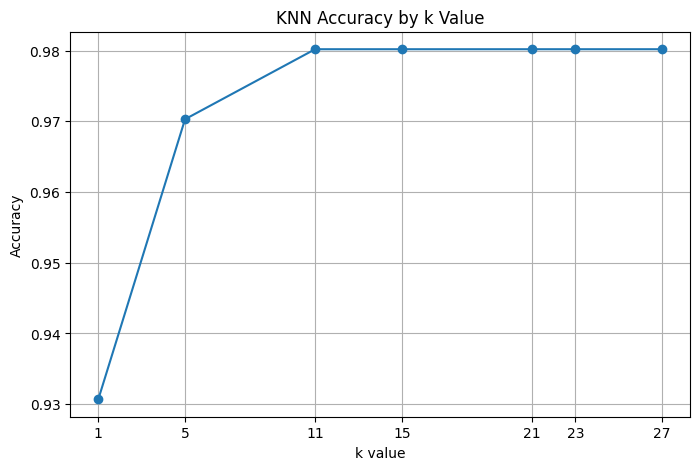

In [15]:
# ============================================================
# 14. k 값별 정확도 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# k 값에 따른 정확도를 선 그래프로 표시합니다.
plt.plot(results_df["k"], results_df["accuracy"], marker="o")

# x축 이름을 설정합니다.
plt.xlabel("k value")

# y축 이름을 설정합니다.
plt.ylabel("Accuracy")

# 그래프 제목을 설정합니다.
plt.title("KNN Accuracy by k Value")

# x축 눈금을 k 값 목록으로 설정합니다.
plt.xticks(k_values)

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 8. 새 데이터 예측 함수

학습된 KNN 모델을 이용하여 새로운 종양 데이터가 들어왔을 때 양성/악성을 예측할 수 있습니다.

주의할 점은 새 데이터도 반드시 훈련 데이터와 같은 방식으로 정규화되어야 한다는 것입니다.

In [16]:
# ============================================================
# 15. 새 데이터 예측 예제
# ============================================================

# 여기서는 테스트 데이터 첫 번째 샘플을 새 데이터처럼 사용합니다.
# 실제 프로젝트에서는 병원 검사 결과로 얻은 30개 수치형 특징이 들어와야 합니다.
new_data_original = X_df.iloc[[468]]

# 새 데이터는 훈련에 사용한 전체 데이터 기준 Min-Max 정규화 방식과 동일하게 변환해야 합니다.
# 여기서는 교육용 간단 구현을 위해 앞에서 만든 X_minmax_df의 같은 행을 사용합니다.
new_data_scaled = X_minmax_df.iloc[[468]].values

# NumPy 배열을 PyTorch Tensor로 변환합니다.
new_data_tensor = torch.tensor(new_data_scaled, dtype=torch.float32).to(device)

# k=23 모델로 새 데이터를 예측합니다.
new_pred_tensor = knn_model.predict(new_data_tensor)

# 예측 숫자 라벨을 가져옵니다.
new_pred_label = int(new_pred_tensor.cpu().numpy()[0])

# 숫자 라벨을 문자열 라벨로 변환합니다.
new_pred_name = class_names[new_pred_label]

# 실제 라벨도 확인합니다.
actual_label = class_names[int(y_encoded[468])]

# 결과를 출력합니다.
print("새 데이터 예측 결과:", new_pred_name)
print("실제 정답:", actual_label)

새 데이터 예측 결과: Malevolent
실제 정답: Malevolent
